# 17 - Decision Tree Regression

> 📘 **Instructor Curriculum**

### The story

Same coaching centre. Same ten students. Same two facts about each of them - videos, and guide.

But the parent standing in front of you today is asking a different question.

- Notebook 16: *"will my son pass?"* → the answer is a **label**: pass or fail.
- This notebook: *"how many marks will my son get?"* → the answer is a **number**: 71, 88, 34.

That one change breaks every measurement you built in notebook 16:

| | Classification (nb 16) | Regression (this one) |
| --- | --- | --- |
| The answer | pass / fail | marks out of 100 |
| A box answers with | the majority label | the **average** of its numbers |
| Mess measured by | entropy | **variance** |
| A split is judged by | information gain | **variance reduction** |
| `score()` gives you | accuracy | **R²** |

The tree itself does not change at all. It still asks yes/no questions and sends people into rooms. Only the **measuring tape** changes - and that is the whole lesson of this notebook.

### Where this is used

| The question | The number |
| --- | --- |
| What is this flat worth? | price in lakhs |
| How long will this delivery take? | minutes |
| How much will this customer spend next month? | rupees |
| How many servers do we need on Sunday? | count |

Anywhere the answer is *how much* or *how many*, instead of *which one*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../02_pandas/DataSet/exam1.csv')

## Step 1 - The same students, now with marks

`result` is no longer a word. It is a mark out of 100.

Line the ten students up by their marks and the shape of the problem jumps straight out:

```
    20   25  30 31 32                        55                      89 90 90 91
    │    │   │  │  │                          │                       │  │  │  │
 ───┴────┴───┴──┴──┴──────────────────────────┴───────────────────────┴──┴──┴──┴──
   row8 row6  0  3  4                        row2                     1  5  9  7

    └────── the low group ──────┘        ← stranded ──→      └──── the high group ────┘
```

Two clear clumps, and one student stranded in the middle with 55.

**Remember row 2.** He decides the score at the end of this notebook.

The tree's job is to find a question that separates the low clump from the high clump.

In [3]:
data

,5me,guide,result
0,0,0,30
1,1,1,89
2,1,0,55
3,0,0,31
4,0,0,32
5,1,1,90
6,0,1,25
7,1,1,91
8,1,0,20
9,1,1,90


## Step 2 - Questions and answer

```
         x  (what you know)              y  (what you want)
        ┌──────┬────────┐                  ┌────────┐
        │ 5me  │ guide  │                  │ result │
        ├──────┼────────┤                  ├────────┤
        │  0   │   0    │                  │   30   │  ← a number now,
        │  1   │   1    │                  │   89   │    not a label
        └──────┴────────┘                  └────────┘
         two brackets = table               one bracket = column
```

One step from notebook 16 disappears here: there is no `LabelEncoder`. You needed it to turn "pass"/"fail" into 1/0. Marks are already numbers.

In [4]:
x=data[['5me','guide']]
y=data['result']

## Step 3 - Hide one student before you start

`train_test_split(x, y, test_size=0.10, random_state=1)` puts 10% of the rows aside. Ten students, so **nine train the tree and one is locked away.**

```
   TRAIN - 9 students                     TEST - 1 student
   rows 9 6 4 0 3 1 7 8 5                 row 2
   the tree studies these                 the tree never sees him
                                          5me=1, guide=0, marks=55
```

`random_state=1` fixes *which* student is picked. Without it you get a different split every run, and two models can never be compared fairly.

Now look at who got locked away: **row 2 - the stranded student from Step 1.** Bad luck, and you will feel it in Step 9.

Why hide anybody at all? A tree can memorise. Scoring it on rows it studied is like grading a student on the exact questions he was given to practise.

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.10, random_state = 1)
print(X_train)
print(y_train)

   5me  guide
9    1      1
6    0      1
4    0      0
0    0      0
3    0      0
1    1      1
7    1      1
8    1      0
5    1      1
9    90
6    25
4    32
0    30
3    31
1    89
7    91
8    20
5    90
Name: result, dtype: int64


## Step 4 - The new measuring tape: variance

Entropy asked *"are these labels mixed?"*. That question means nothing for marks - marks are never "mixed", they are **spread out**. So you measure the spread instead.

**Variance = the average squared distance from the mean.**

```
   tight group                         spread out group
   30  31  32                          20        55        90
    ● ● ●                              ●         ●         ●
    └─┬─┘                              └─────────┬─────────┘
   mean = 31                              mean = 55
   variance ≈ 0.7                       variance ≈ 817
   one number describes all three       one number describes nobody
```

- Small variance = everyone in this box scored about the same.
- Large variance = the box is still holding very different students.

And the answer a box gives is simply **the average of the marks inside it**. That is the regression version of "majority vote".

In [6]:
from sklearn.tree import DecisionTreeRegressor, export_graphviz

## Step 5 - Score the two questions

Start with all nine training students in one box:

```
   90  25  32  30  31  89  91  20  90       mean = 55.33
                                            variance = 972.89   ← the mess to remove
```

Now try each question and measure the mess left behind:

```
        SPLIT ON VIDEOS (5me)                      SPLIT ON GUIDE
   ───────────────────────────────         ───────────────────────────────
    no │ 25  32  30  31                     no │ 32  30  31  20
       │ mean 29.50   var 7.25                 │ mean 28.25   var 23.19
   ────┼──────────────────────────         ────┼──────────────────────────
   yes │ 90  89  91  20  90                yes │ 90  25  89  91  90
       │ mean 76.00   var 784.40               │ mean 77.00   var 676.40
                  ▲                                        ▲
          20 is trapped in the                    25 is trapped in the
          high room - big mess                    high room - big mess

    left over  439.00                       left over  386.08
    removed    533.89                       removed    586.81   ★ WINNER
```

`left over` is the size-weighted average, exactly like Step 4 of notebook 16:

```
(4/9) × 23.19  +  (5/9) × 676.40  =  386.08

Variance Reduction = 972.89 - 386.08 = 586.81
```

**Notice that `guide` wins here, while `5me` won in notebook 16 - same ten students, same two columns.** Nothing is broken. The *question you are answering* changed. The best question for "who passes" is not automatically the best question for "how many marks".

In [7]:
dt = DecisionTreeRegressor()

## Step 6 - Train

`DecisionTreeRegressor()` uses `criterion='squared_error'` by default, which is the variance you just computed. There is no `entropy` option here - entropy has no meaning for numbers.

`dt.fit(X_train, y_train)` repeats Step 5 inside each room until no question helps any more:

```
                9 students      var = 972.89
                       │
            ┌──── had a guide? ────┐
         NO │                      │ YES
            ▼                      ▼
      32  30  31  20         90  25  89  91  90
      var 23.19              var 676.40
            │                      │
     ┌ watched videos? ┐    ┌ watched videos? ┐
   NO│                 │YES NO│                │YES
     ▼                 ▼      ▼                ▼
  32 30 31            20     25          90 89 91 90
  mean = 31       mean = 20  mean = 25    mean = 90
```

Four boxes, four averages: **31, 20, 25, 90.**

**What `fit` leaves behind:** two questions and four numbers. That is the entire model.

In [8]:
dt.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

## Step 7 - Read the rulebook

`export_graphviz(dt, 'dt1.tree', feature_names=['5me','guide'])` writes the tree to a text file. The next cell draws the same tree as a picture, right here in the notebook.

The boxes read differently now:

```
    classification box (nb 16)        regression box (this notebook)
   ┌────────────────────┐            ┌───────────────────────┐
   │ entropy = 0.65     │            │ squared_error = 23.19 │  ← how spread out
   │ samples = 6        │            │ samples = 4           │
   │ value = [1, 5]     │            │ value = 28.25         │  ← the answer
   │ class = pass       │            │                       │
   └────────────────────┘            └───────────────────────┘
     counts per class                  one average, no class line
```

In [9]:
export_graphviz(dt,'dt1.tree',feature_names=['5me','guide'])

Same tree, drawn by sklearn itself. In a **regression** tree the colour no longer means "which class" - it means **how big the number is**. Darker = higher marks.

Read the four leaves along the bottom: **31.0, 20.0, 25.0, 90.0** - the same four averages you worked out in Step 6. Those four numbers are the only answers this model can ever give.

Two details worth catching:

- the root is `guide <= 0.5` with `squared_error = 972.889` and `value = 55.333` - your Step 5 numbers exactly.
- `samples` on the leaves reads 3, 1, 1, 4 = nine students. The tenth is still locked in the vault.

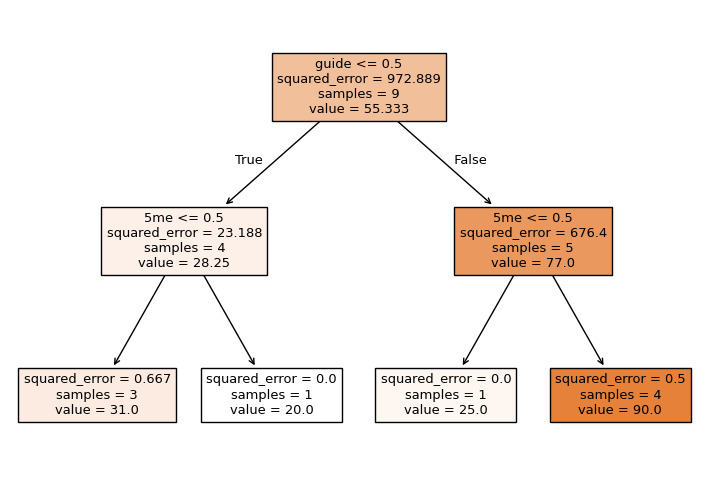

In [10]:
from sklearn.tree import plot_tree

plt.figure(figsize=(9, 6))
plot_tree(dt, feature_names=['5me', 'guide'], filled=True)
plt.show()

## Step 8 - A new student walks in

`dt.predict([[1, 1]])` - watched the videos, had a guide.

```
   new student:  5me = 1,  guide = 1
              │
              ▼
   guide <= 0.5 ?   →  NO  ────────→  go right  (the high room)
              │
              ▼
   5me <= 0.5 ?     →  NO  ────────→  go right
              │
              ▼
   box holding 90, 89, 91, 90   →   answer = their average = 90.0
```

The output is `90.` - and that shows the honest limit of a regression tree. **It can only ever answer with one of its four stored averages.** Ask it about a hundred different students and you still get back 31, 20, 25 or 90. It can never say 73. A straight line (notebook 05, Linear Regression) can. A tree answers in steps.

Double brackets again, because predict wants a table of rows. The warning is the same one as notebook 16 - trained with column names, asked with a bare list.

In [11]:
dt.predict([[1,1]])

/Users/kaliprasad/Documents/MACHINE_LEARNING/pizza_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([90.])

## Step 9 - `score` means something completely different now

⚠️ This is the trap in this notebook. For a classifier, `score` was accuracy - "9 out of 10 correct". **A regressor is almost never exactly right**, so counting correct answers is pointless. `score` returns **R²** instead.

R² answers one question: *how much better is my tree than just saying "55.3 marks" to everybody?*

```
   R² = 1.00   perfect
   R² = 0.86   ← this model
   R² = 0.00   no better than always answering the average
   R² < 0      worse than that
```

The result is **0.8596**, and here is exactly where it comes from. `dt.score(x, y)` was called on **all ten** rows - including the hidden student:

```
   row   actual   tree says    miss
   ─────────────────────────────────
    0      30        31          1
    1      89        90          1
    2      55        20    ✗    35     ← the student we locked away
    3      31        31          0
    4      32        31          1
    5      90        90          0
    6      25        25          0
    7      91        90          1
    8      20        20          0
    9      90        90          0
```

Nine students out of ten are within a single mark. **One student is 35 marks off, and he alone drags the score from 1.00 down to 0.86.**

Look back at the number line in Step 1. Row 2 is the student stranded between the two clumps. The tree only ever saw a low group and a high group, so when he finally arrived it filed him with the low group and answered 20.

Two honest notes:

- `dt.score(x, y)` mixes the nine rows the tree studied with the one it did not. The fair test is `dt.score(X_test, y_test)` - the hidden student on his own.
- The tree got all nine training rows nearly perfect because it was allowed to grow until every box was tiny. That is memorising. On ten rows it is harmless; on real data you hold it back with `max_depth`, or grow many trees and average them - Random Forest.

**If you remember only one thing:** a regression tree is the same tree with two swaps - a box answers with the **average** of the numbers inside it, and a split is judged by how much **variance** it removes.

In [12]:
dt.score(x,y)

0.8596407076209728